# One-Maxwell-To-Rule-Them-All

## Input files
- medium (# $\geq 0$)
- molecule (# $\geq 1$)
- molecule group (# $\geq 1$)
- sources (# $\geq 0$)
- detectors (# $\geq 0$)
  

## Files structure
RunFolder<br>
├── N-N.skf ! Slater-Koster files for each kind of bond <br>
├── ... <br>
├── inp <br>
├── medium_0001.in <br>
├── molecule_0000001.in <br>
├── mol_group_0000001.in <br>
├── sources.in <br>
└── detectors.in

## Notation convention
- \#label $\implies$ the value is a **<u>positive</u>  integer**<br><br>
- <span style="color: #ff4d40">label_1 label_2 label_3</span>, <span style="color: #00baab">label_4 label_5</span>, <span style="color: #9a78ff">label_6</span> <br>
    <span style="color: #ff4d40">label_7 label_8</span>, <span style="color: #00baab">label_9</span>, <span style="color: #9a78ff">label_10</span> $\implies$ if I define label_1 label_2 label_3 then on the next row I have to define ONLY label_7 label_8. <br>
    These are options for different cases. If no comma is present it means the options are the same for ALL the previous cases.<br><br>
- label{"value_1" | "value_2" | "value_3"} $\implies$ mutually exclusive **<u>string</u>** options. label IS NOT an option, just a meaningful name.<br><br>
- [label] $\implies$ optional value<br><br>
- label [...] $\implies$ the line can have 1 or more values corresponding to the same quantity depending on the case<br><br>
- label $\implies$ the value is a real number unless specified differently <br><br>
- Line    &<br>
&continuation<br><br>
- \${label} $\implies$ evaluate expression **label** and returns its value.

## Simulation setup file. Filename: **inp**

## System setup files

### Medium. Filename: **medium_xxxx.in**

### Example: 1D cavity on the x axis.

### Molecule. Filename: **molecule_xxxxxxx.in**

### Example: $\text N_2$ molecule.

### Molecule group. Filename: **mol_group_xxxxxxx.in**

### Example: single molecule simulation.

### Sources. Filename: **sources.in**

$$
f_{\text{source}}(t)=j_{\text{amp}}\exp\left[-\left(\frac{t-t_0}{\tau}\right)^2\right]\cos\left(\omega_0(t-t_0)+\phi\right)\implies \times \text{SpaceKernelMatrix}
$$

$$
\tilde f_{\text{source}} = \frac{j_{\text{amp}}}{2\sqrt{\pi}}\tau\left\{e^{i\phi}\exp\left[-\frac{\tau^2}{4}(\omega - \omega_0)^2\right] + e^{-i\phi}\exp\left[-\frac{\tau^2}{4}(\omega + \omega_0)^2\right]\right\}

$$
|\tilde f_{\text{source}}|^2 = \frac{\tau^2}{2\sqrt{\pi}}j_{\text{amp}}^2\left\{\exp\left[-\frac{\tau^2}{2}(\omega - \omega_0)^2\right] + \exp\left[-\frac{\tau^2}{2}(\omega + \omega_0)^2\right]
+ 2\cos(2\phi)\exp\left[-\frac{\tau^2}{2}(\omega^2 + \omega_0^2)\right]
\right\}
$$

Text(0.5, 0, 'Frequency (eV)')

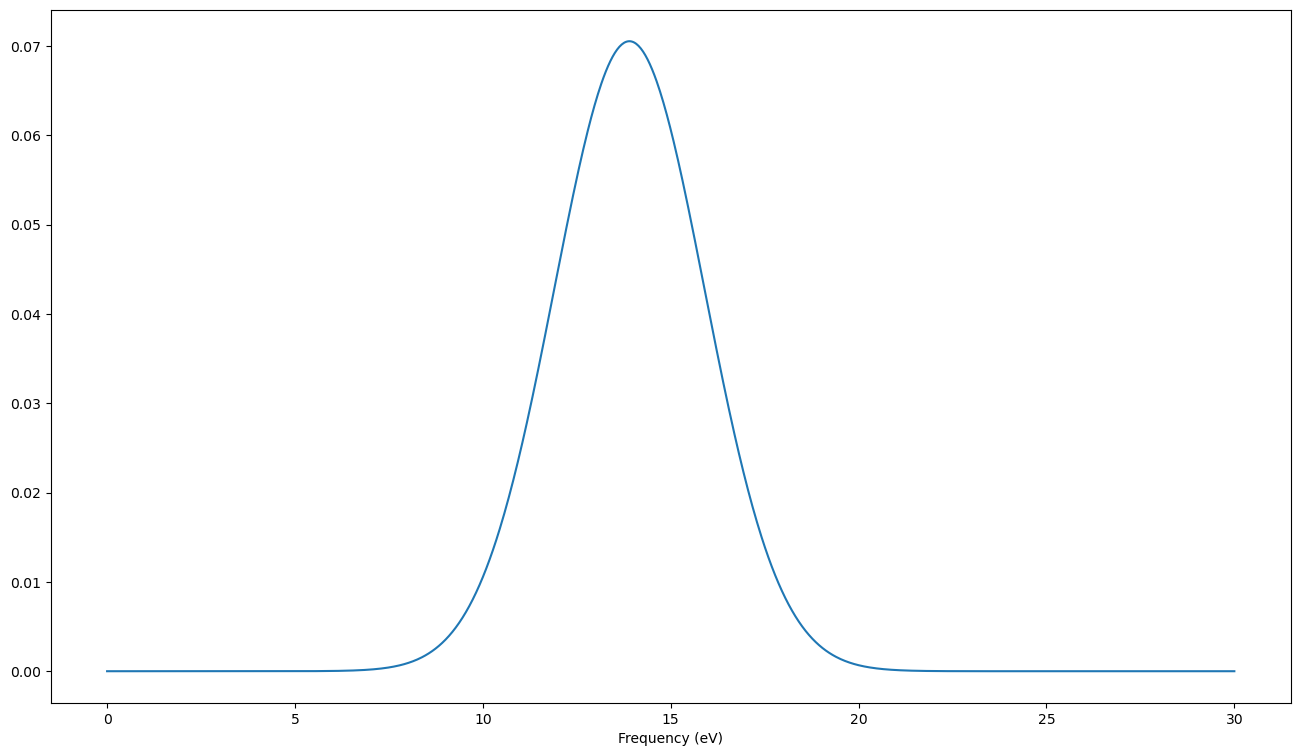

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def build_power(tau, omega_0, j_amp, phi):
    def power(omega):
        return tau**2 / (2.0*np.sqrt(np.pi))*(j_amp**2)*(np.exp(-0.5*tau**2*(omega - omega_0)**2) + np.exp(-0.5*tau**2*(omega + omega_0)**2) + 2*np.cos(2*phi)*np.exp(-0.5*tau**2*(omega**2 + omega_0**2)))
    return power

fig = plt.figure(figsize=(16, 9))
ax = fig.gca()
power = build_power(0.5, 13.9, 1, 0)
x = np.linspace(0, 30, 1000)
ax.plot(x, power(x))
ax.set_xlabel("Frequency (eV)")

### Example: point source on the right hand side of the cavity.

### Detectors. Filename: **detectors.in**

### Example: detecting the electrict field at a single point on the left hand side of the cavity.

## How to run the code

1. Compile the code using **make**
2. Open termnal into the RunFolder
3. Launch the code using /path/to/workspace/build/bin/OMxRTA.e
4. You will find new output files generated in the RunFolder

## Example results

(-1e-09, 1e-09)

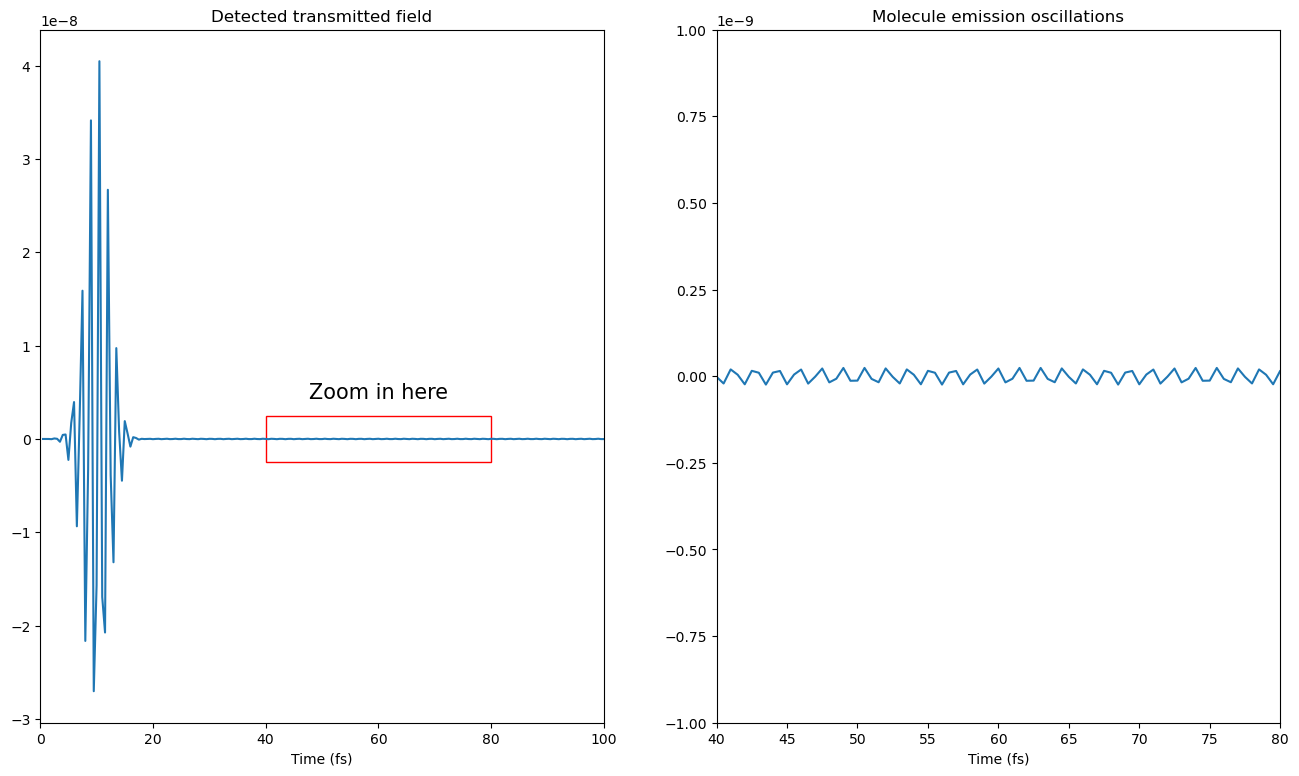

In [28]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.constants
Hartree, _, _ = scipy.constants.physical_constants["Hartree energy"]
Planck, _, _ = scipy.constants.physical_constants["reduced Planck constant"]
au_to_fs = Planck / Hartree * 10**15

detector = np.loadtxt("sample/output_detector_0000001/point.dat")
fig = plt.figure(figsize=(16, 9))
sub1 = fig.add_subplot(121)
sub2 = fig.add_subplot(122)

sub1.set_title("Detected transmitted field")
sub1.plot(
    detector[:, 0] * au_to_fs,
    detector[:, 1]
)
sub1.set_xlabel("Time (fs)")
sub1.set_xlim(0, 100)

rect = patches.Rectangle(
    (40, -0.25e-8),
    40,
    0.5e-8,
    linewidth=1,
    facecolor="None",
    edgecolor="red",
)
sub1.add_patch(rect)

sub1.text(
    60,
    0.5e-8,
    "Zoom in here",
    ha="center",
    va="center",
    fontsize=15
)


sub2.set_title("Molecule emission oscillations")
sub2.plot(
    detector[:, 0] * au_to_fs,
    detector[:, 1]
)
sub2.set_xlabel("Time (fs)")
sub2.set_xlim(40, 80)
sub2.set_ylim(-1e-9, 1e-9)

### Get timesteps

Text(0.5, 0, 'Timestep (fs)')

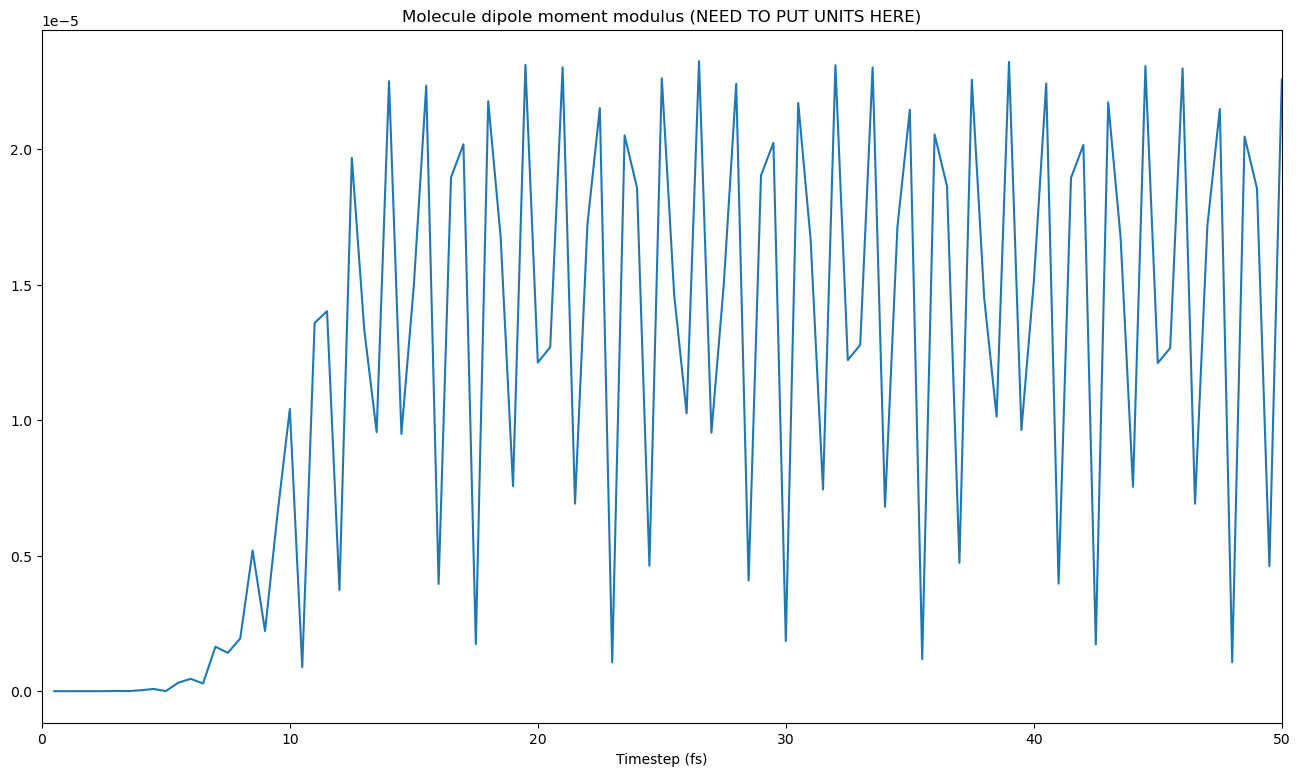

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants
Hartree, _, _ = scipy.constants.physical_constants["Hartree energy"]
Planck, _, _ = scipy.constants.physical_constants["reduced Planck constant"]
au_to_fs = Planck / Hartree * 10**15

# Getting the timesteps from the file
timesteps = []
with open("sample/output_q_group_0001/energy_and_dipole.dat") as f:
    while line := f.readline():
        if "Time" in line:
            match = re.search(r"\d*\.\d*((E|e)?(-|\+)?\d+)?", line)
            timesteps.append(float(match.group(0)))
timesteps = np.array(timesteps)
timesteps *= au_to_fs

energy_and_dipole = np.loadtxt("sample/output_q_group_0001/energy_and_dipole.dat")

fig = plt.figure(figsize=(16, 9))
plt.title("Molecule dipole moment modulus (NEED TO PUT UNITS HERE)")
plt.plot(
    timesteps,
    np.sqrt(np.sum(energy_and_dipole[:, 2:]**2, axis=1))
)
plt.xlim(0, 50)
plt.xlabel("Timestep (fs)")
